# Hyperparameter Sweep Analysis

Analyze `results_hparam_sweep.csv` produced by `hparam_sweep.py`.

Goal: identify which hyperparameters matter, separate hparam effect from init effect.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('../results_hparam_sweep.csv')

# Score: success if gamma > 0.5; treat NaN gamma as 0
df['gamma_filled'] = df['gamma'].fillna(0.0)
df['success'] = df['gamma_filled'] > 0.5

HPARAMS = ['slope', 'temperature', 'beta', 'lr', 'polyak_alpha', 'polyak_beta']

print(f'Total trials: {len(df)}')
print(f'NaN gamma:    {df.gamma.isna().sum()} ({df.gamma.isna().mean():.0%})')
print(f'Success rate: {df.success.mean():.0%}')
df.describe()[HPARAMS + ['init_dist', 'gamma_filled', 'min_loss']].T

Total trials: 364
NaN gamma:    263 (72%)
Success rate: 1%


,count,mean,std,min,25%,50%,75%,max
slope,364.0,5.174027,2.719959,0.569942,2.709919,5.168586,7.634291,9.927568
temperature,364.0,0.291067,0.117667,0.101943,0.195921,0.279294,0.398985,0.499906
beta,364.0,8.077908,4.050480,1.042855,4.506347,8.265380,11.624677,14.975583
lr,364.0,0.201927,0.244288,0.010019,0.027426,0.083468,0.282619,0.984768
polyak_alpha,364.0,1.013899,0.286099,0.501092,0.760120,1.020305,1.247829,1.494598
polyak_beta,364.0,0.748921,0.148081,0.500007,0.617386,0.752903,0.870161,0.999733
init_dist,364.0,0.325886,0.091327,0.117380,0.258576,0.324868,0.388514,0.573889
gamma_filled,364.0,-0.107271,0.342291,-1.000000,0.000000,0.000000,0.000000,0.821092
min_loss,364.0,10.382139,21.527990,0.189796,2.217122,6.836340,15.942286,384.594116


## 0. Failure decomposition

Split NaN-gamma trials into two failure modes:
- **crashed**: training threw (gradient NaN/Inf etc.) → `min_loss` is NaN
- **silent**: training succeeded numerically but recovered params don't spike → `n_spikes_sim == 0` and `min_loss` is finite

If silent dominates, the loss is happily converging to subthreshold solutions (the
classic Guarino failure mode). If crashed dominates, something is numerically broken.

NaN gamma trials: 263 (72%)
  crashed (min_loss=NaN):       0 (0%)
  silent  (n_spikes_sim==0):    263 (72%)
  unexpected (spikes>0 + NaN): 0


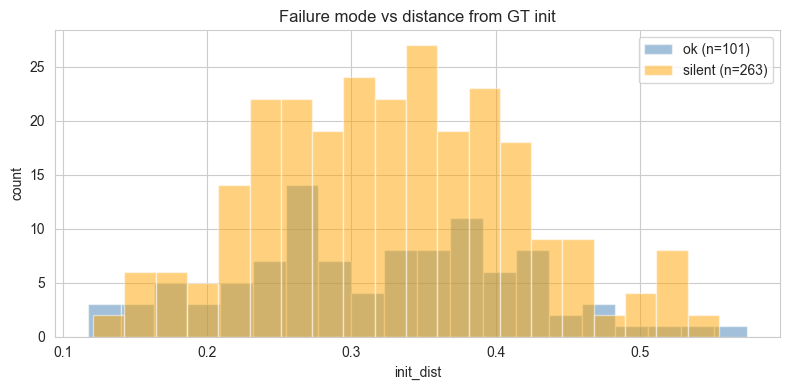

In [2]:
nan_g = df[df.gamma.isna()]
crashed = nan_g[nan_g.min_loss.isna()]
silent = nan_g[nan_g.min_loss.notna() & (nan_g.n_spikes_sim == 0)]
spiking_nan = nan_g[nan_g.n_spikes_sim > 0]  # should be empty by construction

print(f'NaN gamma trials: {len(nan_g)} ({len(nan_g)/len(df):.0%})')
print(f'  crashed (min_loss=NaN):       {len(crashed)} ({len(crashed)/len(df):.0%})')
print(f'  silent  (n_spikes_sim==0):    {len(silent)} ({len(silent)/len(df):.0%})')
print(f'  unexpected (spikes>0 + NaN): {len(spiking_nan)}')

# init_dist distribution per failure mode — does silent convergence happen even from near-GT starts?
ok = df[df.gamma.notna()]
fig, ax = plt.subplots(figsize=(8, 4))
for label, sub, color in [('ok', ok, 'steelblue'),
                          ('silent', silent, 'orange'),
                          ('crashed', crashed, 'red')]:
    if len(sub) > 0:
        ax.hist(sub.init_dist, bins=20, alpha=0.5, label=f'{label} (n={len(sub)})', color=color)
ax.set_xlabel('init_dist'); ax.set_ylabel('count')
ax.set_title('Failure mode vs distance from GT init')
ax.legend(); plt.tight_layout(); plt.show()

## 0b. Which parameter contributes most to failure?

Standardized logistic regression: predict each binary failure outcome from all hparams
+ `init_dist`. After z-scoring features, the magnitude of each coefficient is the
*standardized effect size* — directly comparable across knobs. Sign tells direction
(positive coefficient = higher value of this hparam → more failure).

Three targets:
- **any failure** (NaN gamma): broad picture
- **silent** (training succeeded but no spikes): loss-attractor failures
- **crashed** (gradient NaN/Inf): numerical failures

Random-forest permutation importance shown alongside as a nonlinear sanity check.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from scipy import stats as sstats

features = HPARAMS + ['init_dist']
X_raw = df[features].copy()
X_raw['lr'] = np.log10(X_raw['lr'])  # log-scale lr so unit = decade
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Define targets
df['any_failure'] = df.gamma.isna()
df['silent_target'] = df.gamma.isna() & df.min_loss.notna() & (df.n_spikes_sim == 0)
df['crashed_target'] = df.gamma.isna() & df.min_loss.isna()

targets = ['any_failure', 'silent_target', 'crashed_target']
results = {}

for tgt in targets:
    y = df[tgt].astype(int).values
    if y.sum() == 0 or y.sum() == len(y):
        results[tgt] = None
        continue
    # Logistic regression (standardized coefficients = effect sizes)
    lr = LogisticRegression(max_iter=2000, C=1.0).fit(X, y)
    coefs = pd.Series(lr.coef_[0], index=features)
    # Wald-style p-values via bootstrap (cheap-ish, more honest than statsmodels for small n_failures)
    rng_ = np.random.default_rng(0)
    boot_coefs = np.zeros((200, len(features)))
    for i in range(200):
        idx = rng_.integers(0, len(y), len(y))
        try:
            lr_b = LogisticRegression(max_iter=2000, C=1.0).fit(X[idx], y[idx])
            boot_coefs[i] = lr_b.coef_[0]
        except Exception:
            boot_coefs[i] = np.nan
    se = np.nanstd(boot_coefs, axis=0)
    z = coefs.values / np.where(se > 0, se, np.nan)
    pvals = pd.Series(2 * (1 - sstats.norm.cdf(np.abs(z))), index=features)

    # Random forest permutation importance
    rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=0,
                                min_samples_leaf=3, class_weight='balanced').fit(X, y)
    perm = permutation_importance(rf, X, y, n_repeats=20, random_state=0, n_jobs=-1)
    rf_imp = pd.Series(perm.importances_mean, index=features)

    results[tgt] = {'coef': coefs, 'pval': pvals, 'rf_imp': rf_imp,
                    'n_pos': int(y.sum()), 'auc_train': lr.score(X, y)}

# --- Print summary tables ---
for tgt in targets:
    r = results[tgt]
    if r is None:
        print(f'\n{tgt}: skipped (degenerate)'); continue
    print(f'\n=== {tgt} (n_failures={r["n_pos"]}/{len(df)}) ===')
    summary = pd.DataFrame({
        'std_coef': r['coef'],
        'pval': r['pval'],
        'rf_perm_imp': r['rf_imp'],
    }).sort_values('std_coef', key=lambda s: s.abs(), ascending=False)
    summary['sig'] = summary['pval'].apply(lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')
    print(summary.round(3).to_string())


=== any_failure (n_failures=263/364) ===
              std_coef   pval  rf_perm_imp sig
temperature      0.315  0.011        0.094   *
lr               0.281  0.016        0.088   *
init_dist        0.125  0.332        0.044    
beta            -0.119  0.330        0.063    
slope            0.082  0.525        0.063    
polyak_alpha     0.070  0.560        0.062    
polyak_beta      0.029  0.811        0.099    

=== silent_target (n_failures=263/364) ===
              std_coef   pval  rf_perm_imp sig
temperature      0.315  0.011        0.094   *
lr               0.281  0.016        0.088   *
init_dist        0.125  0.332        0.044    
beta            -0.119  0.330        0.063    
slope            0.082  0.525        0.063    
polyak_alpha     0.070  0.560        0.062    
polyak_beta      0.029  0.811        0.099    

crashed_target: skipped (degenerate)


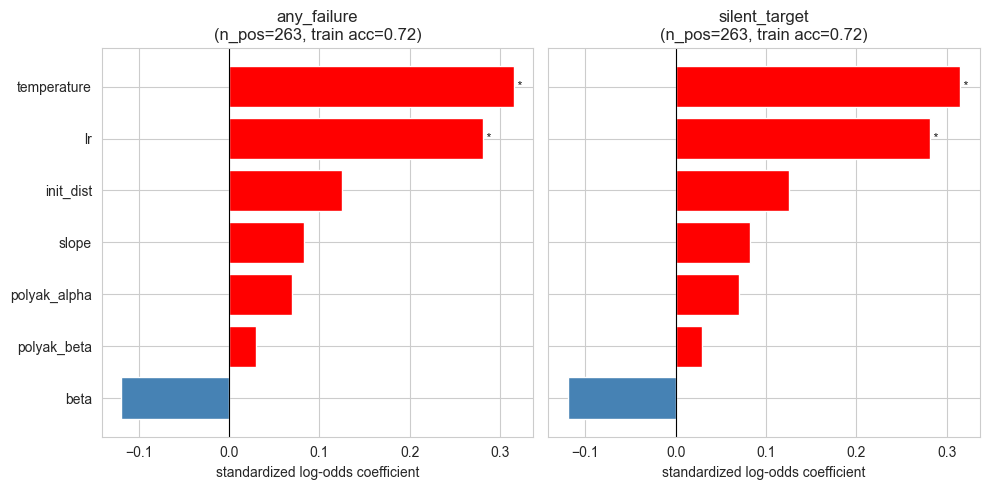


Red bar = increases failure probability. Stars = bootstrap-significance (200 resamples).


In [4]:
# Side-by-side coefficient plot
valid = [t for t in targets if results[t] is not None]
fig, axes = plt.subplots(1, len(valid), figsize=(5 * len(valid), 5), sharey=True)
if len(valid) == 1: axes = [axes]
for ax, tgt in zip(axes, valid):
    r = results[tgt]
    s = r['coef'].sort_values()
    colors = ['red' if c > 0 else 'steelblue' for c in s.values]
    ax.barh(s.index, s.values, color=colors)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_xlabel('standardized log-odds coefficient')
    ax.set_title(f'{tgt}\n(n_pos={r["n_pos"]}, train acc={r["auc_train"]:.2f})')
    # Annotate significance
    for i, (name, val) in enumerate(s.items()):
        p = r['pval'][name]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if sig:
            ax.text(val, i, f' {sig}', va='center', fontsize=9)
plt.tight_layout(); plt.show()
print('\nRed bar = increases failure probability. Stars = bootstrap-significance (200 resamples).')

## 0c. Which *initial parameter* contributes most to failure?

Same logistic-regression analysis as §0b, but on per-parameter initial values
(`init_C_m, init_g_L, init_v_reset, init_v_T, init_E_L, init_delta_T`) instead of
hyperparameters. Tells us whether (e.g.) initializing `v_T` poorly is worse than
initializing `C_m` poorly.

**Requires** the sweep to have logged per-parameter init columns. If the CSV
predates that change, re-run `python hparam_sweep.py`.

In [5]:
init_features = [c for c in df.columns if c.startswith('init_') and c != 'init_dist']
assert init_features, "No init_* columns in CSV. Re-run hparam_sweep.py."
print(f'Init parameters: {init_features}')

X_init_raw = df[init_features].copy()
X_init = StandardScaler().fit_transform(X_init_raw)

init_results = {}
for tgt in targets:
    y = df[tgt].astype(int).values
    if y.sum() == 0 or y.sum() == len(y):
        init_results[tgt] = None
        continue
    lr_ = LogisticRegression(max_iter=2000, C=1.0).fit(X_init, y)
    coefs = pd.Series(lr_.coef_[0], index=init_features)

    rng_ = np.random.default_rng(0)
    boot_coefs = np.zeros((200, len(init_features)))
    for i in range(200):
        idx = rng_.integers(0, len(y), len(y))
        try:
            lr_b = LogisticRegression(max_iter=2000, C=1.0).fit(X_init[idx], y[idx])
            boot_coefs[i] = lr_b.coef_[0]
        except Exception:
            boot_coefs[i] = np.nan
    se = np.nanstd(boot_coefs, axis=0)
    z = coefs.values / np.where(se > 0, se, np.nan)
    pvals = pd.Series(2 * (1 - sstats.norm.cdf(np.abs(z))), index=init_features)

    rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=0,
                                min_samples_leaf=3, class_weight='balanced').fit(X_init, y)
    perm = permutation_importance(rf, X_init, y, n_repeats=20, random_state=0, n_jobs=-1)
    rf_imp = pd.Series(perm.importances_mean, index=init_features)

    init_results[tgt] = {'coef': coefs, 'pval': pvals, 'rf_imp': rf_imp,
                         'n_pos': int(y.sum()), 'auc_train': lr_.score(X_init, y)}

for tgt in targets:
    r = init_results[tgt]
    if r is None:
        print(f'\n{tgt}: skipped (degenerate)'); continue
    print(f'\n=== {tgt} (n_failures={r["n_pos"]}/{len(df)}) ===')
    summary = pd.DataFrame({
        'std_coef': r['coef'],
        'pval': r['pval'],
        'rf_perm_imp': r['rf_imp'],
    }).sort_values('std_coef', key=lambda s: s.abs(), ascending=False)
    summary['sig'] = summary['pval'].apply(lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')
    print(summary.round(3).to_string())

Init parameters: ['init_C_m', 'init_g_L', 'init_v_reset', 'init_v_T', 'init_E_L', 'init_delta_T']

=== any_failure (n_failures=263/364) ===
              std_coef   pval  rf_perm_imp  sig
init_E_L        -1.029  0.000        0.217  ***
init_v_T         0.709  0.000        0.126  ***
init_g_L         0.591  0.000        0.119  ***
init_delta_T    -0.571  0.000        0.098  ***
init_C_m         0.097  0.479        0.046     
init_v_reset     0.078  0.571        0.046     

=== silent_target (n_failures=263/364) ===
              std_coef   pval  rf_perm_imp  sig
init_E_L        -1.029  0.000        0.217  ***
init_v_T         0.709  0.000        0.126  ***
init_g_L         0.591  0.000        0.119  ***
init_delta_T    -0.571  0.000        0.098  ***
init_C_m         0.097  0.479        0.046     
init_v_reset     0.078  0.571        0.046     

crashed_target: skipped (degenerate)


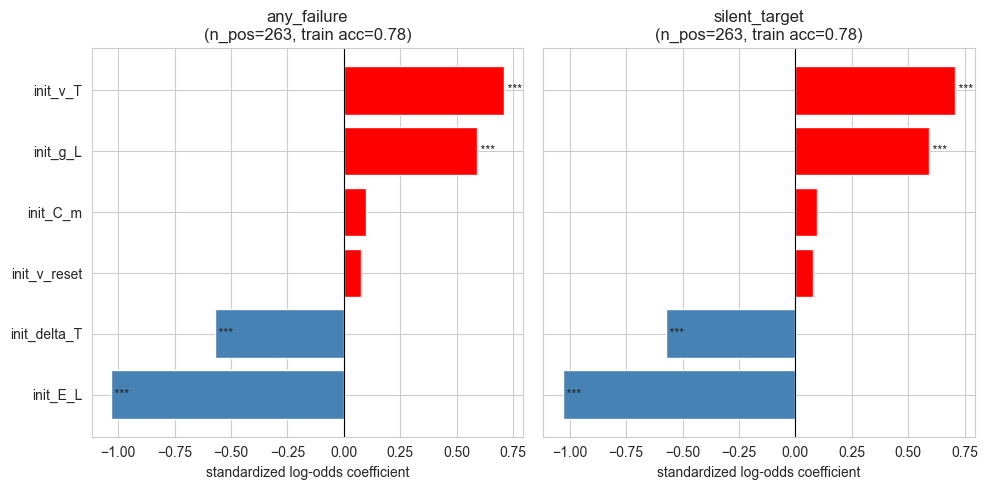


Red bar = higher init value -> more failure. Stars = bootstrap-significance (200 resamples).


In [6]:
valid = [t for t in targets if init_results[t] is not None]
fig, axes = plt.subplots(1, len(valid), figsize=(5 * len(valid), 5), sharey=True)
if len(valid) == 1: axes = [axes]
for ax, tgt in zip(axes, valid):
    r = init_results[tgt]
    s = r['coef'].sort_values()
    colors = ['red' if c > 0 else 'steelblue' for c in s.values]
    ax.barh(s.index, s.values, color=colors)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_xlabel('standardized log-odds coefficient')
    ax.set_title(f'{tgt}\n(n_pos={r["n_pos"]}, train acc={r["auc_train"]:.2f})')
    for i, (name, val) in enumerate(s.items()):
        p = r['pval'][name]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if sig:
            ax.text(val, i, f' {sig}', va='center', fontsize=9)
plt.tight_layout(); plt.show()
print('\nRed bar = higher init value -> more failure. Stars = bootstrap-significance (200 resamples).')

## 0d. Symmetric distance-from-GT analysis

§0c uses raw init values, so a signed coefficient assumes failure is monotonic in
the parameter. But for params like `E_L` or `v_T` both far-below-GT and far-above-GT
inits should hurt — the failure curve is U-shaped, not linear, and the regression
above can confuse "lower → worse" with "the sweep happened to sample asymmetrically".

Two views here:
- **Absolute deviation** `|init - gt|` per param + same logistic regression. All
  significant bars should now be red (more deviation = more failure) regardless of direction.
- **Signed scatter** of `init - gt` vs failure rate per param, with GT marked at 0.
  Reveals whether the U is symmetric, one-sided, or genuinely monotonic.

Ground truth taken from `NAUD_PARAMETERS["tonic"]` (matches `hparam_sweep.py`).

In [7]:
from ADoptEX.core.parameters import NAUD_PARAMETERS

gt = dict(NAUD_PARAMETERS["tonic"])
param_names = [c[len("init_"):] for c in init_features]
gt_values = {p: gt[p] for p in param_names}
print('GT (tonic):', {p: round(v, 4) for p, v in gt_values.items()})

# --- Absolute deviation features ---
abs_features = [f"absdev_{p}" for p in param_names]
X_abs_raw = pd.DataFrame({
    f"absdev_{p}": (df[f"init_{p}"] - gt_values[p]).abs()
    for p in param_names
})
X_abs = StandardScaler().fit_transform(X_abs_raw)

abs_results = {}
for tgt in targets:
    y = df[tgt].astype(int).values
    if y.sum() == 0 or y.sum() == len(y):
        abs_results[tgt] = None
        continue
    lr_ = LogisticRegression(max_iter=2000, C=1.0).fit(X_abs, y)
    coefs = pd.Series(lr_.coef_[0], index=abs_features)

    rng_ = np.random.default_rng(0)
    boot_coefs = np.zeros((200, len(abs_features)))
    for i in range(200):
        idx = rng_.integers(0, len(y), len(y))
        try:
            lr_b = LogisticRegression(max_iter=2000, C=1.0).fit(X_abs[idx], y[idx])
            boot_coefs[i] = lr_b.coef_[0]
        except Exception:
            boot_coefs[i] = np.nan
    se = np.nanstd(boot_coefs, axis=0)
    z = coefs.values / np.where(se > 0, se, np.nan)
    pvals = pd.Series(2 * (1 - sstats.norm.cdf(np.abs(z))), index=abs_features)

    abs_results[tgt] = {'coef': coefs, 'pval': pvals,
                        'n_pos': int(y.sum()), 'auc_train': lr_.score(X_abs, y)}

for tgt in targets:
    r = abs_results[tgt]
    if r is None:
        print(f'\n{tgt}: skipped (degenerate)'); continue
    print(f'\n=== {tgt} | absolute deviation (n_failures={r["n_pos"]}/{len(df)}) ===')
    summary = pd.DataFrame({'std_coef': r['coef'], 'pval': r['pval']}) \
        .sort_values('std_coef', key=lambda s: s.abs(), ascending=False)
    summary['sig'] = summary['pval'].apply(lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')
    print(summary.round(3).to_string())

GT (tonic): {'C_m': 200.0, 'g_L': 10.0, 'v_reset': -58.0, 'v_T': -50.0, 'E_L': -70.0, 'delta_T': 2.0}

=== any_failure | absolute deviation (n_failures=263/364) ===
                std_coef   pval  sig
absdev_E_L         0.915  0.000  ***
absdev_delta_T    -0.455  0.001  ***
absdev_g_L        -0.321  0.014    *
absdev_v_T         0.207  0.099     
absdev_v_reset    -0.108  0.437     
absdev_C_m        -0.012  0.926     

=== silent_target | absolute deviation (n_failures=263/364) ===
                std_coef   pval  sig
absdev_E_L         0.915  0.000  ***
absdev_delta_T    -0.455  0.001  ***
absdev_g_L        -0.321  0.014    *
absdev_v_T         0.207  0.099     
absdev_v_reset    -0.108  0.437     
absdev_C_m        -0.012  0.926     

crashed_target: skipped (degenerate)


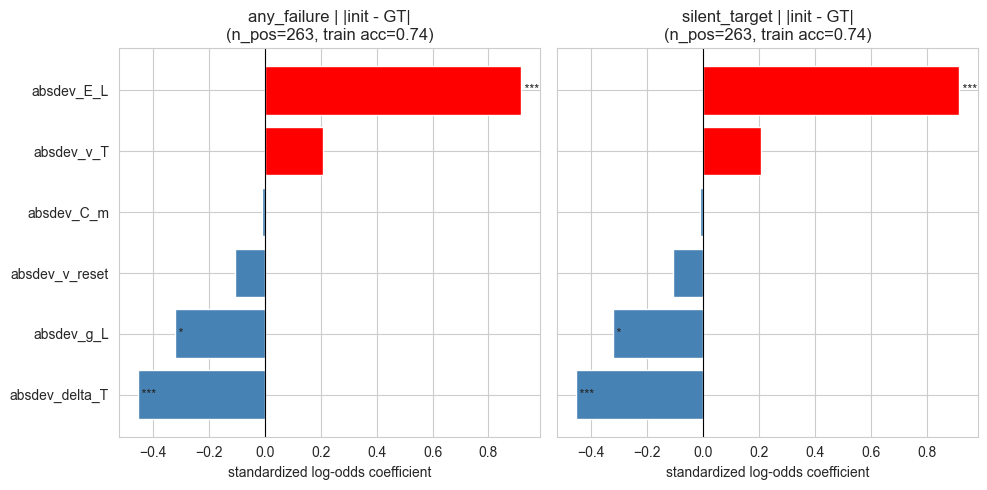


Red bar = larger |init - GT| -> more failure (symmetric distance, direction-agnostic).


In [8]:
# Coefficient bar plot (absolute deviation)
valid = [t for t in targets if abs_results[t] is not None]
fig, axes = plt.subplots(1, len(valid), figsize=(5 * len(valid), 5), sharey=True)
if len(valid) == 1: axes = [axes]
for ax, tgt in zip(axes, valid):
    r = abs_results[tgt]
    s = r['coef'].sort_values()
    colors = ['red' if c > 0 else 'steelblue' for c in s.values]
    ax.barh(s.index, s.values, color=colors)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_xlabel('standardized log-odds coefficient')
    ax.set_title(f'{tgt} | |init - GT|\n(n_pos={r["n_pos"]}, train acc={r["auc_train"]:.2f})')
    for i, (name, val) in enumerate(s.items()):
        p = r['pval'][name]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if sig:
            ax.text(val, i, f' {sig}', va='center', fontsize=9)
plt.tight_layout(); plt.show()
print('\nRed bar = larger |init - GT| -> more failure (symmetric distance, direction-agnostic).')

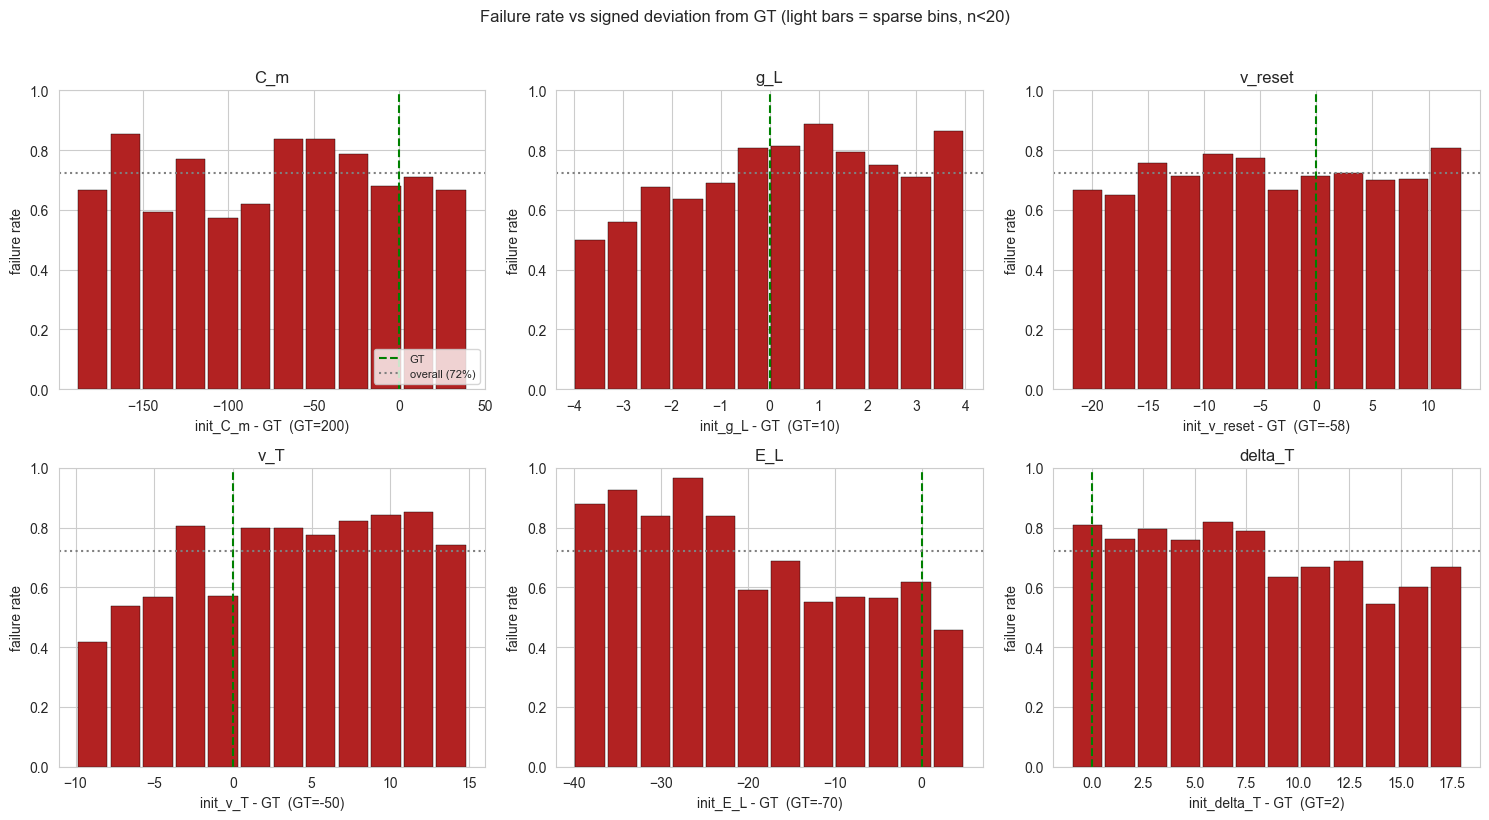

In [9]:
# Signed-deviation scatter: failure rate binned along (init - GT) for each param.
# Reveals whether failure is U-shaped (symmetric), one-sided, or monotonic.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
n_bins = 12
for ax, p in zip(axes.flat, param_names):
    dev = df[f"init_{p}"] - gt_values[p]
    bins = np.linspace(dev.min(), dev.max(), n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    binned = pd.cut(dev, bins, include_lowest=True)
    fail_rate = df.groupby(binned, observed=True)['any_failure'].mean()
    counts = df.groupby(binned, observed=True).size()
    # align to bin centers
    rates = np.array([fail_rate.get(b, np.nan) for b in fail_rate.index])
    cs = np.array([counts.get(b, 0) for b in fail_rate.index])
    bin_centers = np.array([iv.mid for iv in fail_rate.index])

    ax.bar(bin_centers, rates, width=(bins[1]-bins[0])*0.9,
           color=['lightcoral' if c < 20 else 'firebrick' for c in cs],
           edgecolor='k', linewidth=0.3)
    ax.axvline(0, color='green', linestyle='--', linewidth=1.5, label='GT')
    ax.axhline(df.any_failure.mean(), color='gray', linestyle=':', label=f'overall ({df.any_failure.mean():.0%})')
    ax.set_xlabel(f'init_{p} - GT  (GT={gt_values[p]:.3g})')
    ax.set_ylabel('failure rate')
    ax.set_title(p)
    ax.set_ylim(0, 1)
axes[0, 0].legend(fontsize=8, loc='lower right')
plt.suptitle('Failure rate vs signed deviation from GT (light bars = sparse bins, n<20)', y=1.02)
plt.tight_layout(); plt.show()

## 1. Marginal effect of each hyperparameter

Scatter each hparam vs final gamma. Three series:
- **all**: every trial
- **easy** (`init_dist < 0.2`): close starts — isolates hparam effect from init pathology
- **hard** (`init_dist >= 0.2`): far starts — shows whether any hparams rescue bad inits

easy: 28, hard: 336


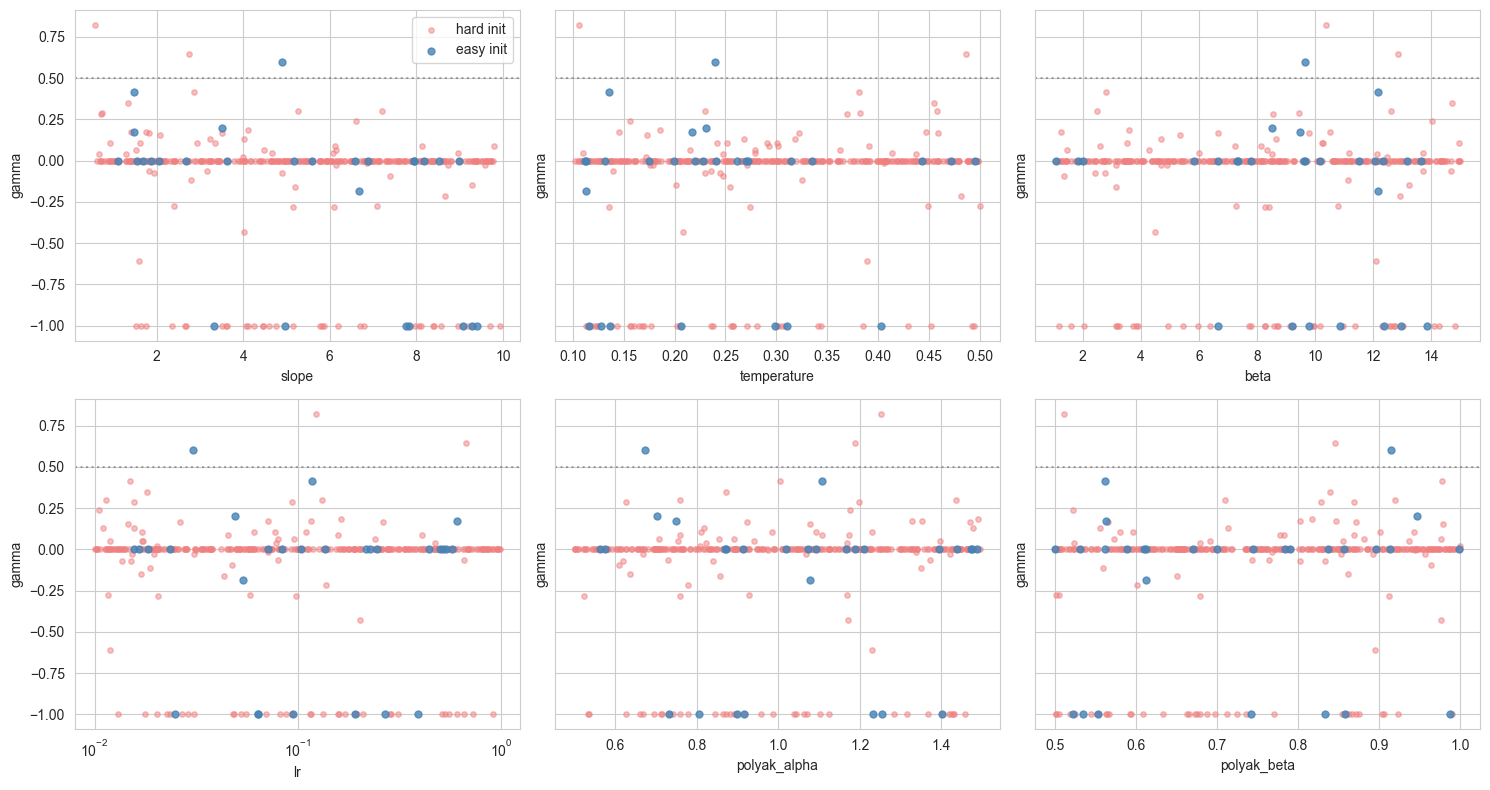

In [10]:
easy = df[df.init_dist < 0.2]
hard = df[df.init_dist >= 0.2]
print(f'easy: {len(easy)}, hard: {len(hard)}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, h in zip(axes.flat, HPARAMS):
    log_x = h == 'lr'
    ax.scatter(hard[h], hard.gamma_filled, c='lightcoral', s=15, alpha=0.5, label='hard init')
    ax.scatter(easy[h], easy.gamma_filled, c='steelblue', s=25, alpha=0.8, label='easy init')
    if log_x: ax.set_xscale('log')
    ax.set_xlabel(h); ax.set_ylabel('gamma')
    ax.axhline(0.5, color='k', linestyle=':', alpha=0.3)
axes[0, 0].legend()
plt.tight_layout(); plt.show()

## 2. 2D interactions

For pairs of hparams that look most interesting, plot scatter colored by gamma.
Use the easy-init subset to remove init confound.

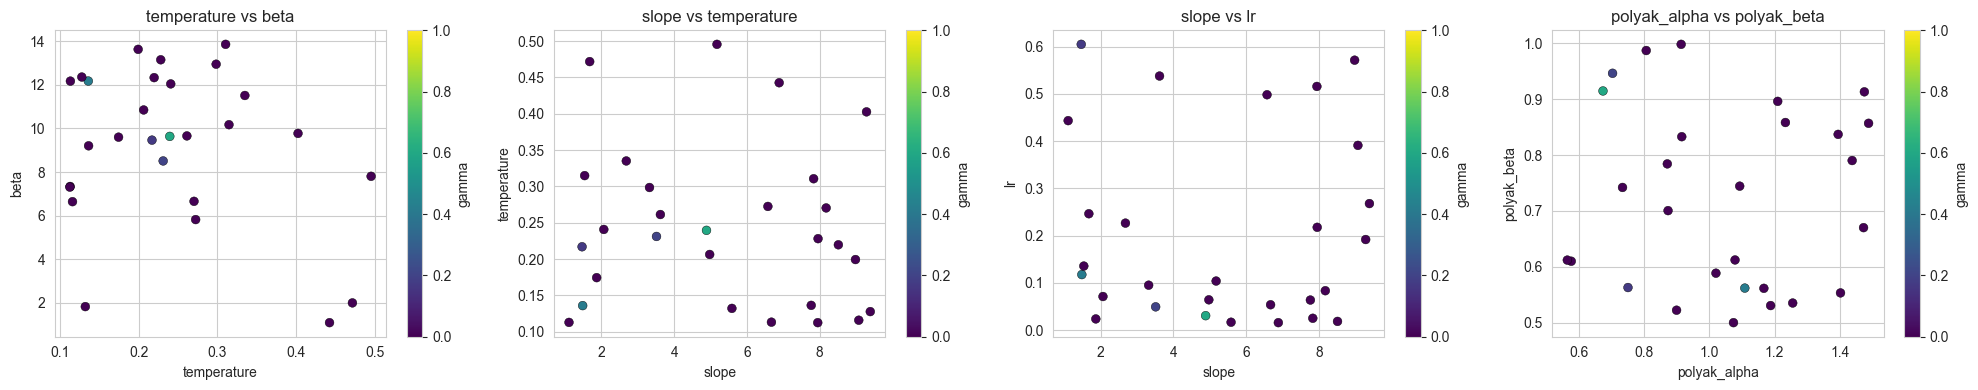

In [11]:
pairs = [('temperature', 'beta'), ('slope', 'temperature'), ('slope', 'lr'),
         ('polyak_alpha', 'polyak_beta')]
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
for ax, (x, y) in zip(axes, pairs):
    sc = ax.scatter(easy[x], easy[y], c=easy.gamma_filled, cmap='viridis',
                    vmin=0, vmax=1, s=40, edgecolors='k', linewidths=0.3)
    if x == 'lr': ax.set_xscale('log')
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(f'{x} vs {y}')
    plt.colorbar(sc, ax=ax, label='gamma')
plt.tight_layout(); plt.show()

## 3. Feature importance via random forest

Fit a RF predicting `gamma_filled` from all hparams + `init_dist`. Importances tell us
which knob actually drives the outcome. Train on full data — `init_dist` is included as
a regressor so it absorbs init variance instead of polluting the others.

R^2 on training data: 0.481


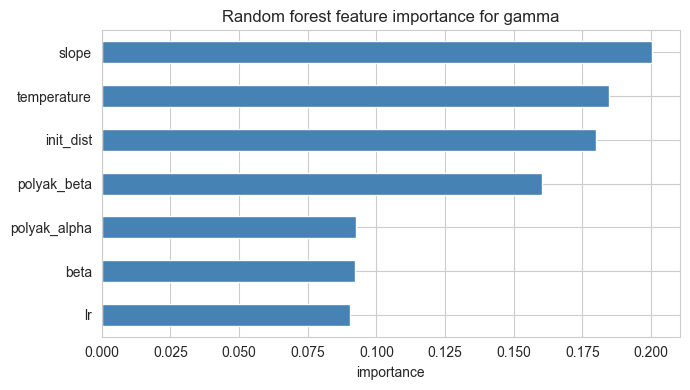

slope           0.200462
temperature     0.184617
init_dist       0.179761
polyak_beta     0.160195
polyak_alpha    0.092541
beta            0.092108
lr              0.090316
dtype: float64

In [12]:
features = HPARAMS + ['init_dist']
X = df[features].copy()
X['lr'] = np.log10(X['lr'])  # log-scale lr so RF splits are interpretable
y = df['gamma_filled']

rf = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=0,
                           min_samples_leaf=3)
rf.fit(X, y)
print(f'R^2 on training data: {rf.score(X, y):.3f}')

imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('importance'); ax.set_title('Random forest feature importance for gamma')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False)

## 4. Top configurations

What do the best trials look like? Helpful for picking a recommended setting.

In [13]:
topk = df.sort_values('gamma_filled', ascending=False).head(10)
print('Top 10 by gamma:')
topk[['trial'] + HPARAMS + ['init_dist', 'gamma_filled', 'min_loss']]

Top 10 by gamma:


,trial,slope,temperature,beta,lr,polyak_alpha,polyak_beta,init_dist,gamma_filled,min_loss
51,51,0.569942,0.106492,10.366524,0.123047,1.251337,0.511640,0.231315,0.821092,0.381452
254,254,2.748292,0.486481,12.846541,0.668960,1.187815,0.845792,0.365397,0.642857,4.349698
87,87,4.887834,0.239544,9.638321,0.030410,0.672987,0.914737,0.145704,0.600000,4.803833
128,128,1.482328,0.135893,12.178051,0.117383,1.108785,0.561910,0.169175,0.416490,1.937840
283,283,2.869182,0.381511,2.816601,0.014903,1.004181,0.977719,0.436753,0.416045,0.967199
363,363,1.333236,0.454534,14.703321,0.018117,0.872892,0.839820,0.324546,0.349206,0.476954
54,54,7.199071,0.229561,12.594723,0.011359,1.435929,0.919735,0.369830,0.297619,0.351061
202,202,5.257041,0.457891,2.481403,0.131095,0.759147,0.710624,0.238398,0.297619,3.411844
226,226,0.736165,0.382109,9.444865,0.093559,1.198097,0.869004,0.382456,0.285714,4.604866
84,84,0.715765,0.369925,8.561987,0.015543,0.625921,0.827906,0.258186,0.284369,0.336302


In [14]:
# Median hparam values among trials with gamma > 0.5 (the 'plateau')
plateau = df[df.gamma_filled > 0.5]
if len(plateau) > 0:
    print(f'\n{len(plateau)} successful trials. Median hparams (the recommended setting):')
    print(plateau[HPARAMS].median().round(3))
    print('\nIQR:')
    print((plateau[HPARAMS].quantile(0.75) - plateau[HPARAMS].quantile(0.25)).round(3))
else:
    print('No successful trials (gamma > 0.5). Re-run with different hparam ranges or more trials.')


3 successful trials. Median hparams (the recommended setting):
slope            2.748
temperature      0.240
beta            10.367
lr               0.123
polyak_alpha     1.188
polyak_beta      0.846
dtype: float64

IQR:
slope           2.159
temperature     0.190
beta            1.604
lr              0.319
polyak_alpha    0.289
polyak_beta     0.202
dtype: float64


## 5. NaN failure modes

Where do gradients explode? Plot the NaN-gamma trials in hparam space — they
should cluster in a recognizable region (e.g. low slope + low temp).

Failed trials: 263 / 364


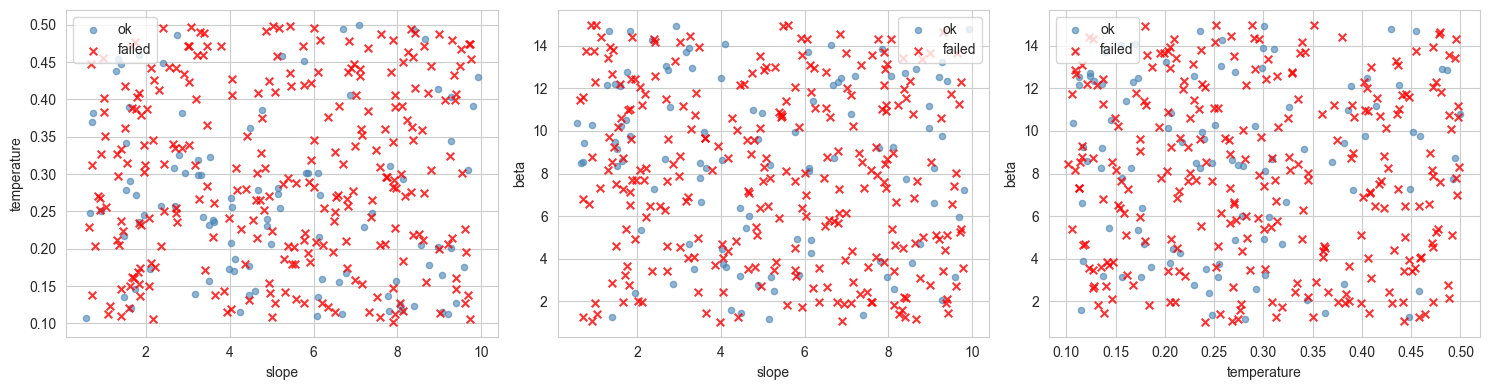

In [15]:
df['failed'] = df.gamma.isna() | (df.n_spikes_sim == 0)
print(f'Failed trials: {df.failed.sum()} / {len(df)}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, [('slope', 'temperature'), ('slope', 'beta'), ('temperature', 'beta')]):
    ax.scatter(df[~df.failed][x], df[~df.failed][y], c='steelblue', s=20, alpha=0.6, label='ok')
    ax.scatter(df[df.failed][x], df[df.failed][y], c='red', s=30, alpha=0.8, marker='x', label='failed')
    ax.set_xlabel(x); ax.set_ylabel(y); ax.legend()
plt.tight_layout(); plt.show()